Para abrir o notebook no Google Colab, altere o domínio `github.com` para `githubtocolab.com`

<div class="alert alert-block alert-danger">
Para praticar programação, é importante que você erre, leia as mensagens de erro e tente corrigí-los.
    
Dessa forma, no Google Colab, é importante que você DESATIVE OS RECURSOS DE AUTOCOMPLETAR:

- Menu Ferramentas -> Configurações
- Na janela que é aberta:
  - Seção Editor -> Desativar "Mostrar sugestões de preenchimento de código com base no contexto"
  - Seção Assistência de IA -> Desabilitar itens

Na versão em inglês:

- Menu Tools -> Settings
- Na janela que é aberta:
  - Seção Editor -> Desativar "Show context-powered code completions"
  - Seção AI Assistance -> Desabilitar itens
</div>

# Exercício 2: Neurônio de Rosenblatt

Um dos experimentos feitos com o perceptron de Rosenblatt consistia na classificação de caracteres. Um caractere era exposto na frente de uma matriz de sensores, que digitalizava a imagem e os elementos dessa matriz eram utilizados como entradas do perceptron.

A ideia consistia em alimentar diversos perceptrons com essas entradas, que funcionariam em paralelo, de forma independente uns dos outros. Cada um era treinado para classificar um determinado caractere, fornecendo saída igual a 1 no caso da detecção do caractere em questão ou -1, no caso da detecção de qualquer outro caractere. Assim, era possível obter uma estrutura com várias saídas, cada uma representando o reconhecimento de um determinado caractere.

Rosenblatt teorizou vários tipos de perceptron aplicados a diferentes aplicações. Dentre estes, estão o *photoperceptron*, para tarefas visuais e o *phonoperceptron*, para tarefas de áudio. Neste exercício, você trabalhará em uma aplicação simplificada do phonoperceptron: um classificador binário utilizando o perceptron de Rosenblatt para determinar se um áudio corresponde a alguém dizendo a palavra "sim" (*yes*) ou "não" (*no*).

Antes de iniciar, certifique-se de ter baixado o arquivo [`train.zip`](./train.zip) com os dados e deixá-lo no mesmo diretório do Jupyter Notebook.

In [5]:
!unzip train.zip -d content

Archive:  train.zip
   creating: content/train/
  inflating: content/train/no212.wav  
  inflating: content/train/no211.wav  
  inflating: content/train/no210.wav  
  inflating: content/train/no21.wav  
  inflating: content/train/no209.wav  
  inflating: content/train/no208.wav  
  inflating: content/train/no207.wav  
  inflating: content/train/no206.wav  
  inflating: content/train/no205.wav  
  inflating: content/train/no204.wav  
  inflating: content/train/no203.wav  
  inflating: content/train/no202.wav  
  inflating: content/train/no201.wav  
  inflating: content/train/no200.wav  
  inflating: content/train/no20.wav  
  inflating: content/train/no2.wav   
  inflating: content/train/no199.wav  
  inflating: content/train/no198.wav  
  inflating: content/train/no197.wav  
  inflating: content/train/no196.wav  
  inflating: content/train/no195.wav  
  inflating: content/train/no194.wav  
  inflating: content/train/no193.wav  
  inflating: content/train/no192.wav  
  inflating: conten

Inicialmente, vamos carregar os arquivos de áudio na matriz **X** e os rótulos correspondentes na uma matriz coluna **Y**.  Para isso pode ser utilizado o código a seguir:

Os áudios são carregados e recebem rótulos:
- 1 -> "yes"
- -1 -> "no"


In [6]:
# Standard Library
# =========================
import os

# =========================
# Visualization
# =========================
import matplotlib.pyplot as plt

# =========================
# Numerical Computing
# =========================
import numpy as np

# =========================
# Audio Processing
# =========================
from scipy.io import wavfile
from scipy.signal import spectrogram

X = []
Y = []
lengths = []
folder = "./content/train/"
files = os.listdir(folder)
for file in files:
    if file.endswith("wav"):
        filepath = os.path.join(folder, file)
        fs, x = wavfile.read(filepath)
        x = x[:30000]
        X.append(x)
        if file.startswith("yes"):
            Y.append(1)
        if file.startswith("no"):
            Y.append(-1)
        lengths.append(len(x))
X = np.array(X)
Y = np.array(Y)

Observe que há um truncamento no tamanho de `X`. Isso ocorre porque os áudios não possuem o mesmo comprimento. Para que os dados possam ser alimentados ao perceptron, é essencial que todos tenham o mesmo tamanho. Por esse motivo, decidiu-se truncar `X` considerando o menor comprimento dos áudios contidos no banco de dados.

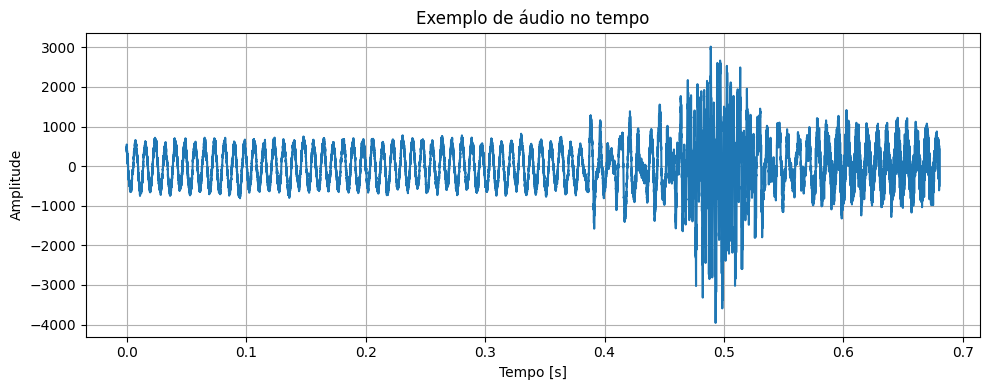

In [7]:
t_step = np.arange(len(X[0])) / fs
plt.figure(figsize=(10, 4))
plt.plot(t_step, X[0])
plt.xlabel("Tempo [s]")
plt.ylabel("Amplitude")
plt.title("Exemplo de áudio no tempo")
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
# Ouvindo o sinal mostrado acima
import soundfile as sf
from IPython.display import Audio

Audio(X[0].T, rate=fs)

A matriz de dados possui 800 linhas e 30000 colunas. Cada linha corresponde a um exemplo do banco de dados. As 30000 colunas representam as amostras de um sinal de áudio discretizado no tempo, ou seja, cada coluna corresponde a uma amostra do sinal de áudio, com frequência de amostragem (fs) de 44100 Hz.

Embora seja possível alimentar a rede diretamente com todas as amostras do sinal de áudio no domínio do tempo (ou seja, utilizando as 30000 colunas como entrada), essa abordagem implica um custo computacional elevado e, em muitos casos, desnecessário. Isso ocorre porque o sinal bruto contém redundâncias e informações irrelevantes para a tarefa de classificação, o que aumenta a dimensionalidade do problema sem necessariamente melhorar o desempenho do modelo.

Para processar melhor o áudio, portanto, sugere-se algum tipo de transformação. Por exemplo, pode-se utilizar como entrada do perceptron o espectrograma de cada sinal. Para isso, utiliza-se uma função da biblioteca SciPy. Não se pode esquecer de concatenar os espectrogramas com os rótulos.



Os sinais de áudio são convertidos para o domínio tempo-frequência usando espectrogramas.

Isso permite representar melhor as características relevantes do áudio.

In [9]:
from scipy.signal import spectrogram

SX = []
Sxyes = []
Sxno = []
n_aud = X.shape[0]
for n in range(n_aud):
    x = X[n, :]
    f, t, Sxx = spectrogram(x, fs, nperseg=256, noverlap=128)
    Sxx = np.log1p(Sxx)
    SX.append(Sxx)
SX = np.array(SX)
SX = SX.reshape(SX.shape[0], -1)
print(f"Tamanho de Sx:{SX.shape}")
Xd = np.hstack((SX, Y.reshape(-1, 1)))

Tamanho de Sx:(800, 30057)


Podemos gerar um gráfico do espectrograma resultante:

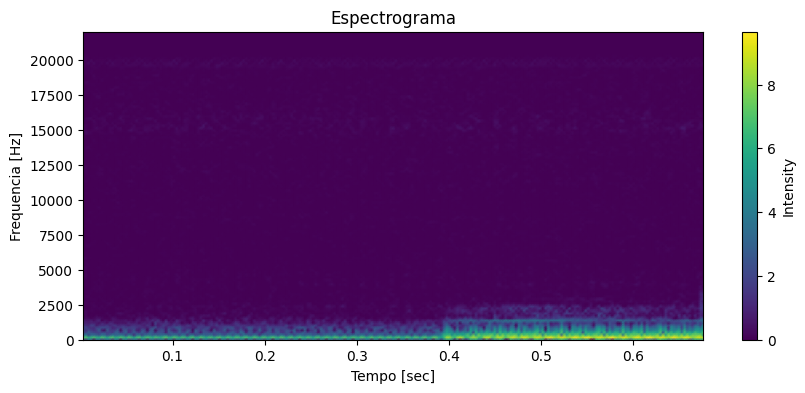

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.pcolormesh(t, f, Sxx, shading="gouraud")
plt.ylabel("Frequencia [Hz]")
plt.xlabel("Tempo [sec]")
plt.title("Espectrograma")
plt.colorbar(label="Intensity")
plt.show()

É aplicado PCA para reduzir a dimensionalidade dos dados, mantendo 95% da variância.

Isso diminui o custo computacional e remove redundâncias.

In [11]:
#PCA
from sklearn.decomposition import PCA
pca = PCA(0.95)  # conserva 95% varianza
X_reduced = pca.fit_transform(SX)

print("Dimensión reducida:", X_reduced.shape)


Dimensión reducida: (800, 407)


Como é possível observar na imagem, a energia do espectrograma concentra-se em uma faixa específica de frequências. A complexidade do perceptron está diretamente relacionada à dimensão do vetor de entrada, ou seja, ao tamanho do vetor de características para cada dado utilizado na entrada.

Por esse motivo, recomenda-se buscar formas de reduzir a dimensionalidade da entrada do modelo, seja utilizando apenas a região do espectrograma que contém informação significativa, seja aplicando outra transformação que permita uma representação mais compacta dos dados. Por exemplo, pode-se utilizar como entrada do perceptron os coeficientes MFCC *(Mel-Frequency Cepstral Coefficients*), utilizar banco de filtros, ou até mesmo utilizar PCA (*Principal Component Analysis*). [Como inspiração, veja algumas transformações nesse artigo](https://arxiv.org/abs/2112.05555).

A atribuição da nota deste exercício levará em consideração tanto o desempenho do modelo quanto o seu custo computacional. É importante deixar claro no vídeo a transformação considerada e o número de pesos do perceptron.

Realizamos a sepração dos dados em treino (70% dos dados) e teste (30% dos dados).

In [12]:
Xd = np.hstack((X_reduced, Y.reshape(-1, 1)))
Xd_train = Xd[:560, :]
Xd_teste = Xd[560:, :]
X_train = Xd_train[:, :-1]
X_test = Xd_teste[:, :-1]

O rótulo referente à imagem pode ser obtido com o elemento da última coluna:

In [13]:
y_train = Xd_train[:, -1]
y_test = Xd_teste[:, -1]
print(y_train.shape)
print(y_test.shape)


(560,)
(240,)


Como você pode observar, o rótulo igual a 1 é usado para identificar a palavra *yes* e o rótulo igual a -1 é usado para identificar a palavra  *no*.

Você deve implementar uma função para treinar o perceptron de Rosenblatt de forma iterativa, dados a matriz `Xd`, um passo de adaptação `eta`, o número de épocas `Ne` e o tamanho do *mini-batch* `Nb`. Após o treinamento, avalie o seu modelo com os dados dos conjuntos de treinamento e de teste, medindo a acurácia do classificador para ambos os casos. A escolha desses hiperparâmetros fica a critério do aluno, devendo-se buscar uma configuração que proporcione um bom desempenho no conjunto de dados de teste.

Além disso, deve-se também implementar um modelo de classificação baseado em regressão logística, comparando a acurácia obtida no conjunto de teste entre os dois modelos. **Observação importante: Utilize somente a biblioteca NumPy para a implementação do perceptron e da regressão logística.**


A acurácia ou taxa de acerto é definida como o número de predições corretas realizadas pelo modelo dividido pelo número total de predições. Ou seja, a acurária é o complementar da taxa de erro.

**Observação: Essa medida deve ser calculada com os dados de teste para verificar a qualidade do modelo.**



O perceptron realiza classificação usando uma função sinal.

Os pesos são atualizados apenas quando ocorre erro na predição.

In [14]:
#perceptron
def perceptron_train(X, y, eta=0.01, epochs=20):
    N, M = X.shape

    # añadir bias
    Xb = np.hstack((np.ones((N,1)), X))
    w = np.zeros(M + 1)
    for epoch in range(epochs):
        for i in range(N):
            xi = Xb[i]
            d = y[i]
            v = np.dot(xi, w)
            y_pred = 1 if v >= 0 else -1
            e = d - y_pred
            if e != 0:
                w = w+eta*e*xi
    return w

def perceptron_predict(X, w):
    Xb = np.hstack((np.ones((X.shape[0],1)), X))
    v = Xb @ w
    return np.where(v >= 0, 1, -1)

A regressão logística utiliza uma função sigmoide para gerar probabilidades.

Depois, um limiar é usado para realizar a classificação.

In [15]:

#REGRESIÓN LOGÍSTICA

def sigmoid(v):
    return 1 / (1 + np.exp(-v))

def logistic_train(X, y, eta=0.01, epochs=20):
    N, M = X.shape

    # convertir labels
    y = (y + 1) / 2

    Xb = np.hstack((np.ones((N,1)), X))
    w = np.zeros(M + 1)

    for epoch in range(epochs):
        for i in range(N):
            xi = Xb[i]
            d = y[i]
            v = np.dot(xi, w)
            y_pred = sigmoid(v)
            e = d - y_pred
            w = w+eta*e*xi

    return w

def logistic_predict(X, w):
    Xb = np.hstack((np.ones((X.shape[0],1)), X))
    y_prob = sigmoid(Xb @ w)

    # volver a -1,1
    return np.where(y_prob >= 0.5, 1, -1)

#ENTRENAMIENTO
w_perc = perceptron_train(X_train, y_train)
w_log = logistic_train(X_train, y_train)

A acurácia é calculada como a proporção de classificações corretas.

In [19]:
#EVALUACIÓN
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

# Perceptrón
y_train_pred = perceptron_predict(X_train, w_perc)
y_test_pred = perceptron_predict(X_test, w_perc)

acc_train_perc = accuracy(y_train, y_train_pred)
acc_test_perc = accuracy(y_test, y_test_pred)

#Logística
y_train_pred_log = logistic_predict(X_train, w_log)
y_test_pred_log = logistic_predict(X_test, w_log)

acc_train_log = accuracy(y_train, y_train_pred_log)
acc_test_log = accuracy(y_test, y_test_pred_log)


# RESULTADOS
print("\nPERCEPTRÓN")
print("Train accuracy:", acc_train_perc)
print("Test accuracy:", acc_test_perc)

print("\nREGRESIÓN LOGÍSTICA")
print("Train accuracy:", acc_train_log)
print("Test accuracy:", acc_test_log)


PERCEPTRÓN
Train accuracy: 1.0
Test accuracy: 1.0

REGRESIÓN LOGÍSTICA
Train accuracy: 1.0
Test accuracy: 0.9916666666666667


Ambos os modelos apresentaram alta acurácia tanto no conjunto de treino quanto no conjunto de teste.

Isso indica que o problema é praticamente linearmente separável com as características utilizadas.

Não foi observada uma diferença significativa entre os dois modelos neste caso.

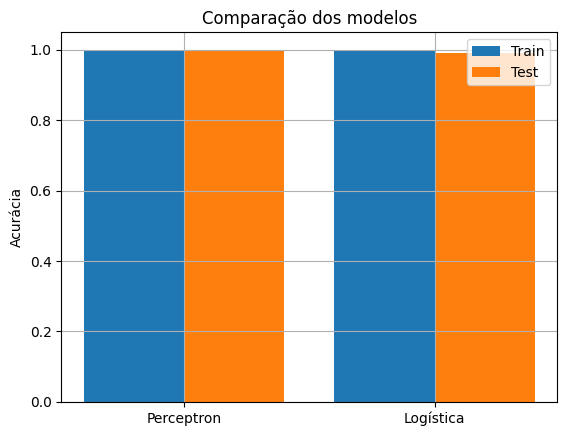

In [17]:
models = ["Perceptron", "Logística"]
train_acc = [acc_train_perc, acc_train_log]
test_acc = [acc_test_perc, acc_test_log]

x = np.arange(len(models))

plt.figure()
plt.bar(x - 0.2, train_acc, width=0.4, label="Train")
plt.bar(x + 0.2, test_acc, width=0.4, label="Test")

plt.xticks(x, models)
plt.ylabel("Acurácia")
plt.title("Comparação dos modelos")
plt.legend()
plt.grid()

plt.show()


Ao final do exercício, você deverá apresentar:

1. Os códigos utilizados para treinar o modelo e avaliá-lo com os conjuntos de treinamento e de teste;

2. O valor obtido para a acurácia considerando os dados de teste tanto para o perceptron de Rosenblatt quanto para a regressão logística.

A sugestão é que o relatório seja elaborado utilizando um Jupyter Notebook e a linguagem Python, já que essas são as ferramentas que estamos utilizando nesta parte do curso. No entanto, isso não é obrigatório e você pode usar outra linguagem de programação, caso queira.

## Instruções para entrega

- O exercício pode ser feito em dupla ou individualmente;

- A entrega deve incluir:
  - Um vídeo de no **máximo 40s**, mostrando a resolução do exercício;
  - Os **códigos-fontes** dos programas, preferencialmente organizados em um Jupyter Notebook, descrevendo o experimento e mostrando como foram obtidos os resultados solicitados.

- **A correção será feita baseada no vídeo**. Quando o professor/pesquisador ficar com alguma dúvida, serão consultados os códigos-fonte;

- Sobre o vídeo:
  - **Deve incluir áudio** descrevendo o experimento;
  - Gravem a tela do computador usando celular ou usando algum programa de captura de tela (por exemplo Zoom, Google Meet, ou OBS Studio);
  - No início, **deve aparecer o rosto e algum documento do aluno que gravou o vídeo** (como a carteira USP, RG, CNH, etc);
  - No caso de entrega em dupla, **não é necessário que os dois componentes apareçam no vídeo**. No entanto, alternem o apresentador ao longo das entregas dos exercícios e **não esqueçam de incluir os dois nomes no início do vídeo**.
  - Procurem convencer o espectador do vídeo, que vai corrigir o exercício que fizeram os exercícios computacionais solicitados e que eles estão funcionando corretamente. Tentem fazer um bom aproveitamento do tempo para apresentar os resultados solicitados, **respeitando o limite de 40s e não acelerem a velocidade do vídeo**;

- Sobre os códigos-fonte:
  - **Incluir o nome do(s) aluno(s)** no início do programa;

- Sobre o envio no Moodle:
  - Apenas um aluno de cada dupla deve enviar o vídeo no Moodle;
  - Podem ser enviados o arquivo de vídeo (.mkv, .mp4, .avi, etc.) ou um link para o vídeo (Youtube, Google Drive, etc);
    - No segundo caso, certifiquem-se que todos os professores/pesquisadores (magno.silva@usp.br, hae.kim@usp.br, sergiocaceres01@usp.br, renatocan@lps.usp.br) tenham acesso ao seu vídeo.
  - Não se esqueçam de escrever o nome dos componentes da dupla (ou do único aluno, escrevendo: "exercício feito individualmente") em três lugares diferentes: **no campo "comentários sobre o envio" no Moodle**, **no início do vídeo** e no **início dos códigos-fonte**.

